In [1]:
# Task

# First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

#     Which states have the most sales?
#     What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
#     Who is an outstanding customer in New York?
#     Are there any differences among states in profitability?
#     The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
#     What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
#     What are the Top 20 customers by Sales?
#     Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
#     Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_excel('US Superstore data.xls')
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df_raw.shape

(9994, 21)

In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [10]:
df_raw.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [11]:
df = df_raw.copy()
# Examining duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [14]:
#Examining rows w duplicate Order ID
df.duplicated(subset=['Order ID']).sum()


np.int64(4985)

In [16]:
duplicated_df = df[df.duplicated(subset=['Order ID'],keep=False)]
duplicated_df    

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,9988,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-AC-10001539,Technology,Accessories,Logitech G430 Surround Sound Gaming Headset wi...,79.9900,1,0.00,28.7964
9988,9989,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.1000,5,0.00,55.6470
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932


In [29]:
#Conclusion: Rows with duplicate Order ID are normal, as they have different items ordered.
# I want to understand the sales column: is it total sales for that product (product price * quantity or only item price?)
# To do so I will look at rows with the same product ID.
df[df.duplicated(subset=['Product ID'],keep=False)].sort_values('Product ID')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
5494,5495,CA-2014-105249,2014-11-28,2014-11-28,Same Day,DH-13675,Duane Huffman,Home Office,United States,San Francisco,...,94122,West,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",411.332,4,0.15,-4.8392
1760,1761,CA-2015-130785,2015-09-05,2015-09-09,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,San Diego,...,92105,West,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",411.332,4,0.15,-4.8392
6401,6402,CA-2017-125472,2017-05-30,2017-05-31,First Class,BD-11725,Bruce Degenhardt,Consumer,United States,Lafayette,...,70506,South,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",241.960,2,0.00,33.8744
1594,1595,CA-2015-118423,2015-03-24,2015-03-27,First Class,DP-13390,Dennis Pardue,Home Office,United States,Peoria,...,61604,Central,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases,359.058,3,0.30,-35.9058
2603,2604,CA-2016-165848,2016-06-04,2016-06-04,Same Day,EN-13780,Edward Nazzal,Consumer,United States,New York City,...,10035,East,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases,136.784,1,0.20,5.1294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7501,7502,CA-2017-121048,2017-07-14,2017-07-18,Standard Class,TC-21295,Toby Carlisle,Consumer,United States,Westminster,...,92683,West,TEC-PH-10004977,Technology,Phones,GE 30524EE4,470.376,3,0.20,52.9173
7477,7478,CA-2014-167199,2014-01-06,2014-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,391.980,2,0.00,113.6742
9727,9728,CA-2017-167395,2017-12-02,2017-12-04,First Class,KM-16720,Kunst Miller,Consumer,United States,Lowell,...,1852,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,979.950,5,0.00,284.1855
581,582,CA-2017-145233,2017-12-01,2017-12-05,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Denver,...,80219,West,TEC-PH-10004977,Technology,Phones,GE 30524EE4,470.376,3,0.20,52.9173


In [25]:
#We see that the Sales column in fact is different for different quanitites of the same Product ID so it captures the total sales (Product Price * Quantity.)
# Now for missing values:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [36]:
#No missing values.
#     Which states have the most sales?
state_sums = df.groupby('State')[['Sales','Quantity','Discount','Profit']].sum()
print('Top Ten States by Sales:')
state_sums.sort_values('Sales', ascending=False).head(10)

Top Ten States by Sales:


,Sales,Quantity,Discount,Profit
State,,,,
California,457687.6315,7667,145.60,76381.3871
New York,310876.2710,4224,62.40,74038.5486
Texas,170188.0458,3724,364.64,-25729.3563
Washington,138641.2700,1883,32.40,33402.6517
Pennsylvania,116511.9140,2153,192.90,-15559.9603
Florida,89473.7080,1379,114.65,-3399.3017
Illinois,80166.1010,1845,191.90,-12607.8870
Ohio,78258.1360,1759,152.40,-16971.3766
Michigan,76269.6140,946,1.80,24463.1876


In [46]:
#     What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
## We see the sales and profit for New York and California above.
sales_diff = state_sums.loc['California', 'Sales'] - state_sums.loc['New York', 'Sales']
profit_diff = state_sums.loc['California', 'Profit'] - state_sums.loc['New York', 'Profit']
print(f"Sales difference (CA - NY): ${sales_diff:.2f}")
print(f"Profit difference (CA - NY): ${profit_diff:.2f}")

Sales difference (CA - NY): $146811.36
Profit difference (CA - NY): $2342.84


In [55]:
#     Who is an outstanding customer in New York?
# For this we can filter out all values to State == New York and then group data by customers to see sales and profits.
NYData = df[df['State']=='New York']
NYCustomers = NYData.groupby('Customer ID')[['Sales','Profit']].sum()
print('NY Customer with Highest Sales:')
print(NYCustomers.sort_values('Sales',ascending=False).head(1))
print('\nNY Customer with Highest Profit:')
print(NYCustomers.sort_values('Profit',ascending=False).head(1))

NY Customer with Highest Sales:
                 Sales     Profit
Customer ID                      
TA-21385     13723.498  4599.2073

NY Customer with Highest Profit:
                 Sales     Profit
Customer ID                      
TA-21385     13723.498  4599.2073


In [93]:
#So we see Customer TA-21385 is the outstanding customer in New York.

#     Are there any differences among states in profitability?
## Using profitability as Profit Margin (profit/revenue), or here, profit/sales, let us add a profitability column:

state_sums['Profitability'] = state_sums['Profit'] / state_sums['Sales']
print('Total Data by State (Sorted by Profitability, descending):')
state_sums.sort_values('Profitability',ascending=False)

Total Data by State (Sorted by Profitability, descending):


,Sales,Quantity,Discount,Profit,Profitability
State,,,,,
District of Columbia,2865.0200,40,0.00,1059.5893,0.369837
Delaware,27451.0690,367,0.60,9977.3748,0.363460
Minnesota,29863.1500,331,0.00,10823.1874,0.362426
Maine,1270.5300,35,0.00,454.4862,0.357714
Arkansas,11678.1300,240,0.00,4008.6871,0.343264
Indiana,53555.3600,578,0.00,18382.9363,0.343251
Georgia,49095.8400,705,0.00,16250.0433,0.330986
Montana,5589.3520,56,1.00,1833.3285,0.328004
Rhode Island,22627.9560,199,1.20,7285.6293,0.321975


In [74]:
#     The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
# Steps to do this:
# 1. Determine Total Profit
total_profit = df['Profit'].sum()
print(f'Total profit: {total_profit:.2f}')
# 2. Group data by Customer ID and show Profit, sort by profit.
CustomerProfits = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False)
CustomerProfits

Total profit: 286397.02


Customer ID
TC-20980    8981.3239
RB-19360    6976.0959
SC-20095    5757.4119
HL-15040    5622.4292
AB-10105    5444.8055
              ...    
HG-14965   -2797.9635
SR-20425   -3333.9144
LF-17185   -3583.9770
GT-14635   -4108.6589
CS-12505   -6626.3895
Name: Profit, Length: 793, dtype: float64

In [80]:
# 3. Calculate number of Customers and thus 20% of that number.
TwentyPCcustomers = round(len(CustomerProfits)*0.2)
TwentyPCcustomers

159

In [88]:
# 4. Sum profit for top 20% of customers. (Can use df.nlargest(#,'column')).
# Divide that by total Profits
Top20CustProfitPerc = ((sum(CustomerProfits.nlargest(TwentyPCcustomers))) / total_profit) * 100
print(f'The top 20% of customers produced {Top20CustProfitPerc:.2f}% of profits.')
print('This is over 80%, so the Pareto Principle is true here.')

The top 20% of customers produced 81.66% of profits.
This is over 80%, so the Pareto Principle is true here.


In [94]:
#     What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
CityData = df.groupby('City')[['Sales','Profit']].sum()
CityData['Profitability'] = CityData['Profit'] / CityData['Sales']

print('Top 20 Cities by Sales:')
CityData.sort_values('Sales',ascending=False).head(20)

Top 20 Cities by Sales:


,Sales,Profit,Profitability
City,,,
New York City,256368.1610,62036.9837,0.241984
Los Angeles,175851.3410,30440.7579,0.173105
Seattle,119540.7420,29156.0967,0.243901
San Francisco,112669.0920,17507.3854,0.155388
Philadelphia,109077.0130,-13837.7674,-0.126862
Houston,64504.7604,-10153.5485,-0.157408
Chicago,48539.5410,-6654.5688,-0.137096
San Diego,47521.0290,6377.1960,0.134197
Jacksonville,44713.1830,-2323.8350,-0.051972


In [96]:
print('Top 20 Cities by Profit:')
CityData.sort_values('Profit',ascending=False).head(20)

Top 20 Cities by Profit:


,Sales,Profit,Profitability
City,,,
New York City,256368.161,62036.9837,0.241984
Los Angeles,175851.341,30440.7579,0.173105
Seattle,119540.742,29156.0967,0.243901
San Francisco,112669.092,17507.3854,0.155388
Detroit,42446.944,13181.7908,0.310547
Lafayette,25036.200,10018.3876,0.400156
Jackson,24963.858,7581.6828,0.303706
Atlanta,17197.840,6993.6629,0.406659
Minneapolis,16870.540,6824.5846,0.404527


In [98]:
print('Top 20 Cities by Profitability:')
CityData.sort_values('Profitability',ascending=False).head(20)

Top 20 Cities by Profitability:


,Sales,Profit,Profitability
City,,,
Atlantic City,23.360,11.6800,0.500000
Grand Island,15.960,7.9800,0.500000
New Brunswick,14.770,7.1567,0.484543
Summerville,406.940,196.9132,0.483888
Holland,137.860,66.6588,0.483525
Antioch,19.440,9.3312,0.480000
Davis,32.400,15.5520,0.480000
Royal Oak,35.340,16.9632,0.480000
Lindenhurst,55.480,26.6304,0.480000


In [112]:
#     What are the Top 20 customers by Sales?
CustomerSales = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False)
Top20CustomerSales = CustomerSales.head(20)
print('Top 20 Customers by Sales:')
Top20CustomerSales

Top 20 Customers by Sales:


Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
TS-21370    11891.751
GT-14710    11820.120
BM-11140    11789.630
SV-20365    11470.950
CJ-12010    11164.974
CL-12565    10880.546
ME-17320    10663.728
KF-16285    10604.266
BS-11365    10501.653
EH-13765    10310.880
Name: Sales, dtype: float64

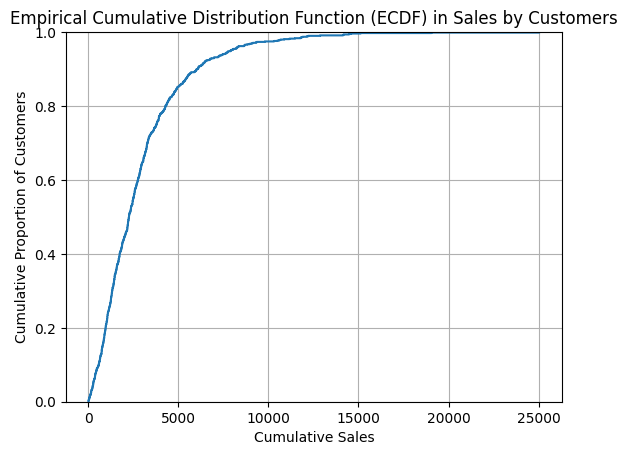

In [109]:
#     Plot the Cumulative curve in Sales by Customers.
sns.ecdfplot(data=CustomerSales)
plt.title('Empirical Cumulative Distribution Function (ECDF) in Sales by Customers')
plt.xlabel('Cumulative Sales')
plt.ylabel('Cumulative Proportion of Customers')
plt.grid(True)
plt.show()

In [114]:
# Can we apply Pareto principle to customers and Sales ?
# 1. Determine Total Sales
total_sales = df['Sales'].sum()
# 2. Group data by Customer ID and show Sales, sort by Sales.
#Already Done (CustomerSales dataframe.)
# 3. Calculate number of Customers and thus 20% of that number.
TwentyPCcustomers = round(len(CustomerProfits)*0.2)
#(Twenty % of the # of Customers is the same as in the CustomerProfits Table.)
# 4. Sum profit for top 20% of customers. (Can use df.nlargest(#,'column')).
# Divide that by total Profits
Top20CustSalesPerc = ((sum(CustomerSales.nlargest(TwentyPCcustomers))) / total_sales) * 100
print(f'The top 20% of customers produced {Top20CustSalesPerc:.2f}% of sales.')
print('Thus, the Pareto Principle is not valid for Customers and Sales.')

The top 20% of customers produced 48.15% of sales.
Thus, the Pareto Principle is not valid for Customers and Sales.


In [119]:
# Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

## Marketing should focus on the states and cities with the highest potential for increasing profits.
# I estimate that the most promising localities on this front are those with high profitability up to now. So I will find the top ten most profitable states and cities:
#Ten most profitable states:
state_sums.sort_values('Profitability',ascending=False).head(10)

,Sales,Quantity,Discount,Profit,Profitability
State,,,,,
District of Columbia,2865.020,40,0.0,1059.5893,0.369837
Delaware,27451.069,367,0.6,9977.3748,0.363460
Minnesota,29863.150,331,0.0,10823.1874,0.362426
Maine,1270.530,35,0.0,454.4862,0.357714
Arkansas,11678.130,240,0.0,4008.6871,0.343264
Indiana,53555.360,578,0.0,18382.9363,0.343251
Georgia,49095.840,705,0.0,16250.0433,0.330986
Montana,5589.352,56,1.0,1833.3285,0.328004
Rhode Island,22627.956,199,1.2,7285.6293,0.321975


In [125]:
#And here as a list of states:
state_sums.sort_values('Profitability', ascending=False).head(10).index.tolist()

['District of Columbia',
 'Delaware',
 'Minnesota',
 'Maine',
 'Arkansas',
 'Indiana',
 'Georgia',
 'Montana',
 'Rhode Island',
 'Michigan']

In [127]:
#Ten most profitable cities:
CityData.sort_values('Profitability', ascending=False).head(10)

,Sales,Profit,Profitability
City,,,
Atlantic City,23.36,11.6800,0.500000
Grand Island,15.96,7.9800,0.500000
New Brunswick,14.77,7.1567,0.484543
Summerville,406.94,196.9132,0.483888
Holland,137.86,66.6588,0.483525
Antioch,19.44,9.3312,0.480000
Davis,32.40,15.5520,0.480000
Royal Oak,35.34,16.9632,0.480000
Lindenhurst,55.48,26.6304,0.480000


In [128]:
#And as a list of cities:
CityData.sort_values('Profitability', ascending=False).head(10).index.tolist()

['Atlantic City',
 'Grand Island',
 'New Brunswick',
 'Summerville',
 'Holland',
 'Antioch',
 'Davis',
 'Royal Oak',
 'Lindenhurst',
 'Bozeman']